In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.metrics import classification_report
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:

# Load the training data
train = pd.read_csv('/kaggle/input/predict-the-success-of-bank-telemarketing/train.csv')

# EDA

In [3]:
print("\nDataset Info:")
print(train.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39211 entries, 0 to 39210
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   last contact date  39211 non-null  object
 1   age                39211 non-null  int64 
 2   job                38982 non-null  object
 3   marital            39211 non-null  object
 4   education          37744 non-null  object
 5   default            39211 non-null  object
 6   balance            39211 non-null  int64 
 7   housing            39211 non-null  object
 8   loan               39211 non-null  object
 9   contact            28875 non-null  object
 10  duration           39211 non-null  int64 
 11  campaign           39211 non-null  int64 
 12  pdays              39211 non-null  int64 
 13  previous           39211 non-null  int64 
 14  poutcome           9760 non-null   object
 15  target             39211 non-null  object
dtypes: int64(6), object(10)
m

In [4]:
print("\nBasic Statistics:")
train.describe()


Basic Statistics:


,age,balance,duration,campaign,pdays,previous
count,39211.000000,39211.000000,39211.000000,39211.000000,39211.000000,39211.000000
mean,42.120247,5441.781719,439.062789,5.108770,72.256051,11.826171
std,12.709352,16365.292065,769.096291,9.890153,160.942593,44.140259
min,18.000000,-8019.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,98.000000,109.000000,1.000000,-1.000000,0.000000
50%,40.000000,549.000000,197.000000,2.000000,-1.000000,0.000000
75%,50.000000,2030.000000,380.000000,4.000000,-1.000000,0.000000
max,95.000000,102127.000000,4918.000000,63.000000,871.000000,275.000000


### Quick Statistical Insights

#### Age
* Range: 18-95 years
* Median: 40 years
* Most customers (50%) between 33-50 years

#### Balance
* Wide range: -€8,019 to €102,127
* Median: €549
* High variability (std: €16,365)

#### Duration
* Range: 0-4,918 seconds (up to 82 mins)
* Median: 197 seconds (~3.3 mins)
* 75% of calls under 380 seconds

#### Campaign
* Most customers contacted 1-4 times
* Median: 2 contacts
* Some extreme cases of 63 contacts

#### Previous & Pdays
* 75% of customers have no previous contacts
* Maximum of 275 previous contacts
* Most pdays values are -1 (no previous contact)

In [5]:
print("\nMissing Values:")
train.isnull().sum()


Missing Values:


last contact date        0
age                      0
job                    229
marital                  0
education             1467
default                  0
balance                  0
housing                  0
loan                     0
contact              10336
duration                 0
campaign                 0
pdays                    0
previous                 0
poutcome             29451
target                   0
dtype: int64

### Missing Values Analysis

#### Complete Features (No Missing Values)
* Basic customer info: age, marital status, default status
* Financial metrics: balance, housing, loan
* Campaign metrics: duration, campaign, pdays, previous
* Target variable and contact date are complete

#### Features with Missing Values
* **Contact Information**
  * Contact method: 10,336 missing (26.4% of data)
  * Previous outcome (poutcome): 29,451 missing (75.1% of data)

* **Customer Profile**
  * Job information: 229 missing (0.6% of data)
  * Education level: 1,467 missing (3.7% of data)

In [6]:
print("\nDistribution of Categorical Variables:")
for col in [c for c in train.select_dtypes(include=['object']).columns if c != 'last contact date']:
    print(f"\n{col}:")
    print(train[col].value_counts(normalize=True))



Distribution of Categorical Variables:

job:
job
blue-collar      0.199477
management       0.191422
technician       0.155918
admin.           0.105587
services         0.085296
self-employed    0.047766
retired          0.046791
entrepreneur     0.046303
unemployed       0.043225
housemaid        0.042481
student          0.035734
Name: proportion, dtype: float64

marital:
marital
married     0.578690
single      0.286909
divorced    0.134401
Name: proportion, dtype: float64

education:
education
secondary    0.518864
tertiary     0.307731
primary      0.173405
Name: proportion, dtype: float64

default:
default
no     0.94244
yes    0.05756
Name: proportion, dtype: float64

housing:
housing
yes    0.55232
no     0.44768
Name: proportion, dtype: float64

loan:
loan
no     0.811507
yes    0.188493
Name: proportion, dtype: float64

contact:
contact
cellular     0.86684
telephone    0.13316
Name: proportion, dtype: float64

poutcome:
poutcome
failure    0.507070
other      0.262295
succ

### Job Distribution Analysis

#### Top Job Categories
* Blue-collar workers: 19.9% of customers
* Management positions: 19.1% of customers
* Technicians: 15.6% of customers
* Administrative roles: 10.6% of customers
* Service sector: 8.5% of customers

#### Target Variable Distribution
* Negative responses (no): 85.1%
* Positive responses (yes): 14.9%

#### Marital Status
* Married: 57.9%
* Single: 28.7%
* Divorced: 13.4%

#### Key Observations
* Strong class imbalance in target variable (approximately 6:1 ratio)
* Professional distribution skews towards skilled labor and management
* Top 5 job categories account for ~73% of the dataset
* Married individuals form majority of customer base
* Need for balanced sampling or weighted strategies in modeling

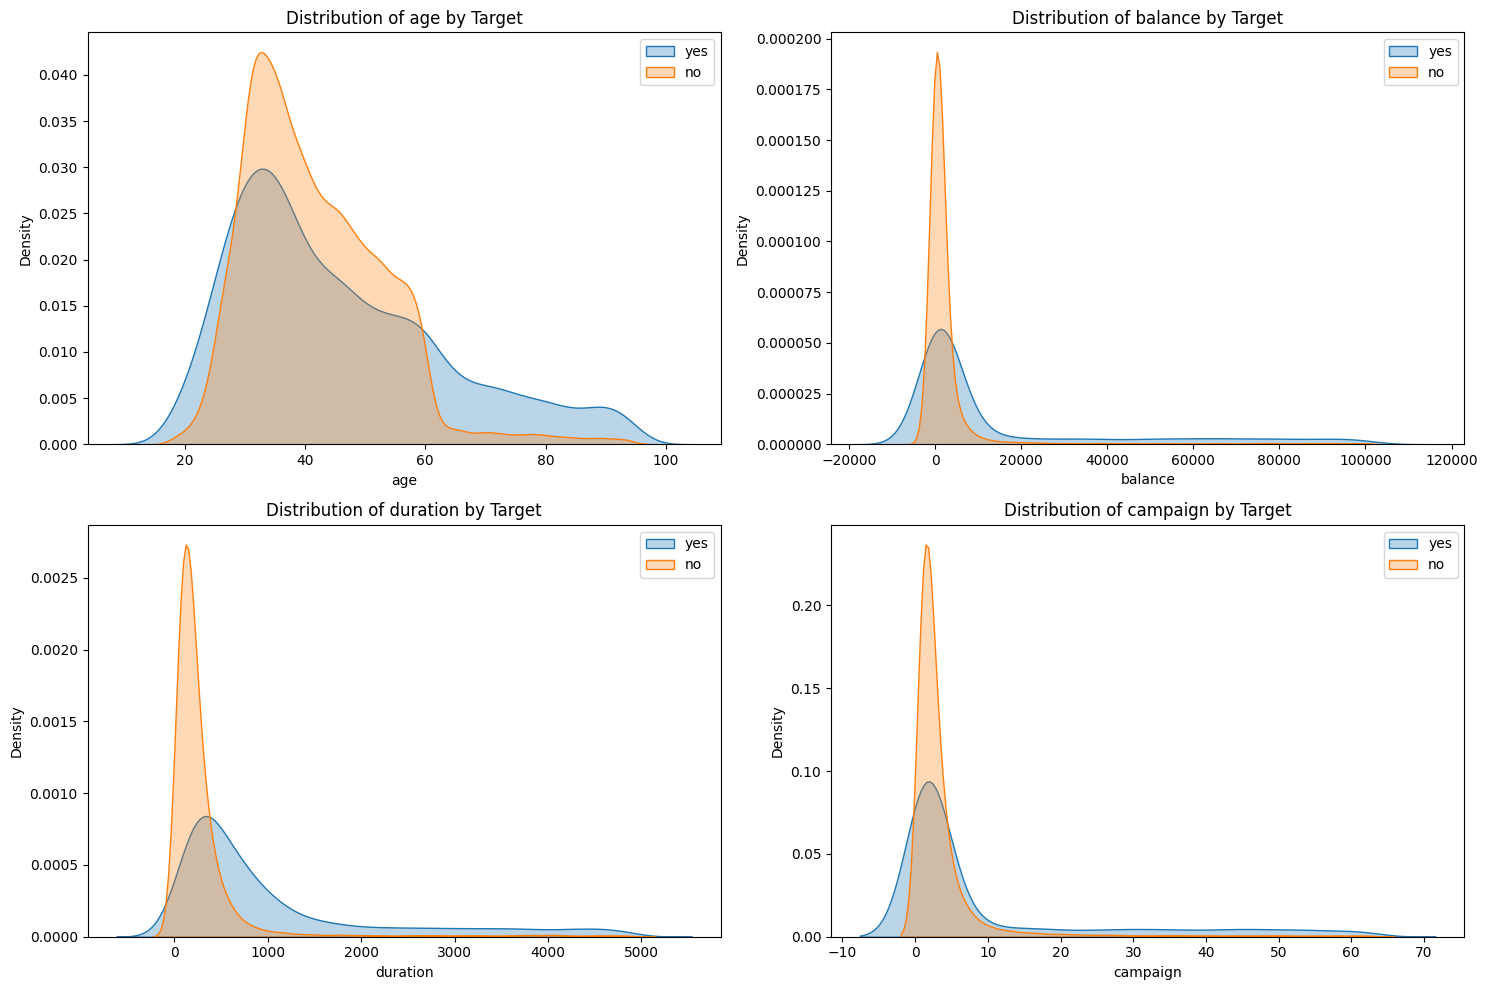

In [7]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# Define numerical columns
numerical_cols = train.select_dtypes(include=['int64', 'float64']).columns

# Create KDE plots to show distribution shapes
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols[:4], 1):
    plt.subplot(2, 2, i)
    sns.kdeplot(data=train[train['target']=='yes'][col], label='yes', fill=True, alpha=0.3)
    sns.kdeplot(data=train[train['target']=='no'][col], label='no', fill=True, alpha=0.3)
    plt.title(f'Distribution of {col} by Target')
    plt.legend()
plt.tight_layout()
plt.show()

### Distribution Analysis by Target Variable

#### Age Distribution
- The majority of customers are between 30-40 years old for both target classes.
- The success rate ("yes") remains relatively steady across most age groups.
- A slight decline in both responses is observed after age 60.
- The ratio of "yes" to "no" is more balanced among middle-aged customers (35-45 years).
- Very few customers are under 20 or over 90 years old.

#### Balance Distribution
- The distribution is heavily right-skewed.
- Most customers have account balances below 20,000.
- A significant concentration of accounts is near a zero balance.
- No clear separation in balance trends is observed between "yes" and "no" responses.
- A small number of outliers have balances exceeding 60,000.

#### Duration Distribution
- The distribution is highly right-skewed for both target classes.
- The majority of calls last less than 1,000 seconds.
- Call duration peaks around 200-300 seconds.
- Longer call durations show a slight association with "yes" responses.
- Calls exceeding 3,000 seconds are rare.

#### Campaign Distribution
- The distribution is strongly right-skewed.
- Most customers were contacted fewer than five times.
- There is a steep drop in frequency after 10 contacts.
- The pattern is similar for both successful and unsuccessful outcomes.
- Campaigns with more than 30 contacts are extremely rare.


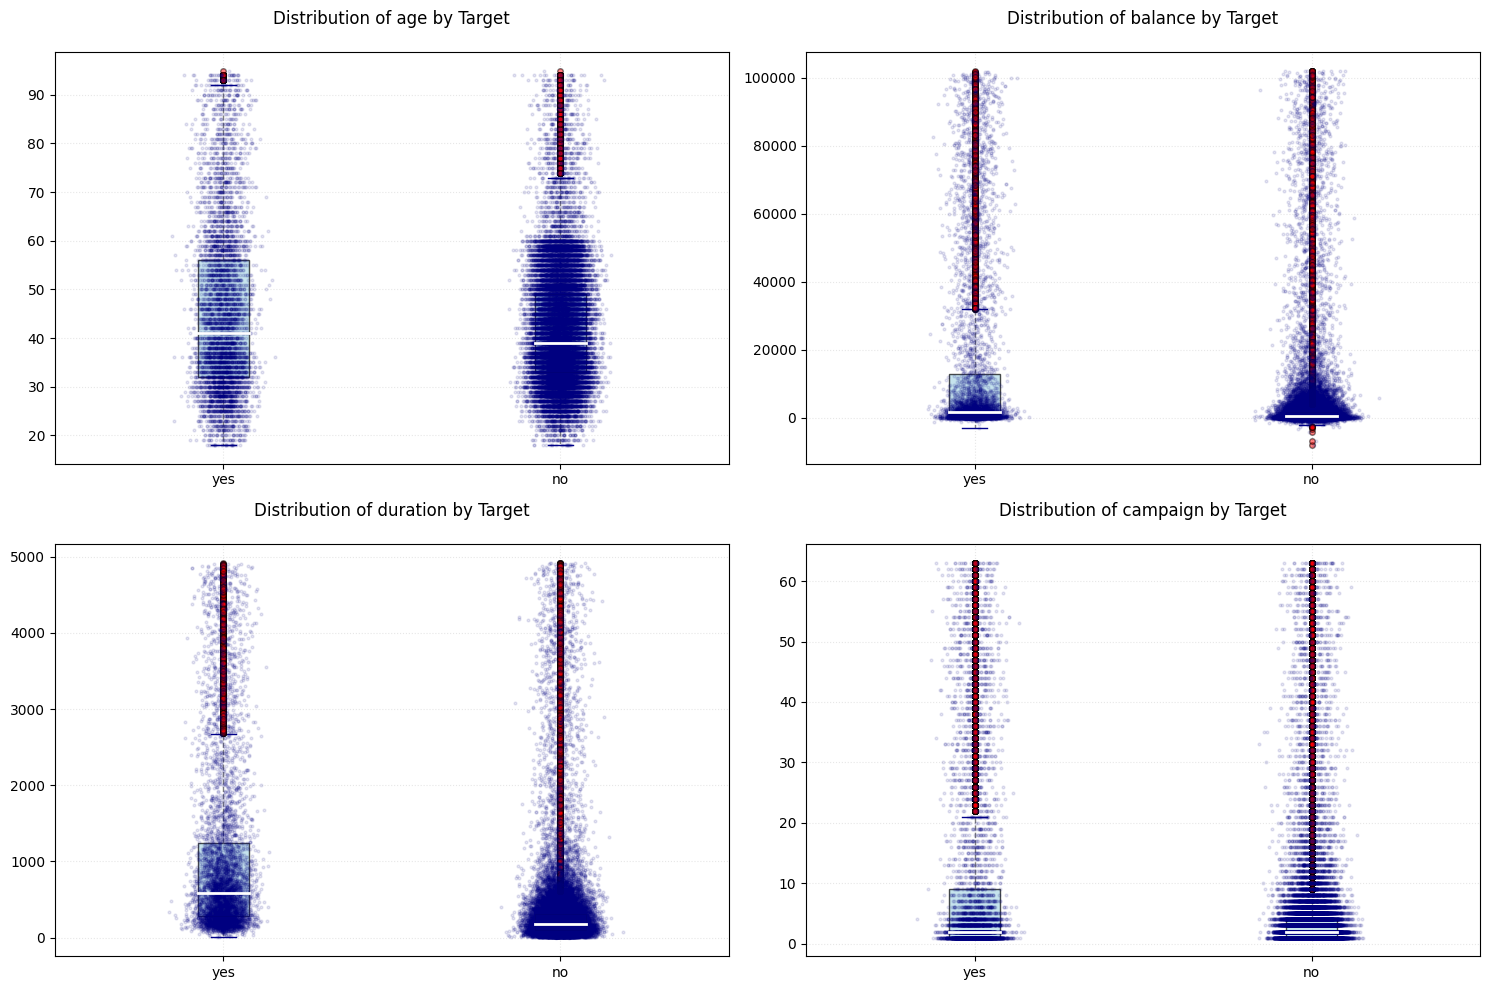

In [8]:

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols[:4], 1):
    plt.subplot(2, 2, i)
    # Create custom box plot with unique style
    bp = plt.boxplot([train[train['target']=='yes'][col], train[train['target']=='no'][col]], 
                     patch_artist=True,
                     medianprops=dict(color="white", linewidth=2),
                     flierprops=dict(marker='o', markerfacecolor='red', markersize=4, alpha=0.5),
                     whiskerprops=dict(linestyle='--', color='gray'),
                     boxprops=dict(facecolor='lightblue', alpha=0.7),
                     capprops=dict(color='darkblue'))
    
    # Add jittered points
    for j, target in enumerate(['yes', 'no']):
        x = np.random.normal(j+1, 0.04, size=len(train[train['target']==target][col]))
        plt.plot(x, train[train['target']==target][col], 'o', 
                alpha=0.1, color='navy', markersize=2)
    
    plt.title(f'Distribution of {col} by Target', pad=20)
    plt.xticks([1, 2], ['yes', 'no'])
    plt.grid(True, alpha=0.3, linestyle=':')
plt.tight_layout()
plt.show()

### Box Plot Analysis by Target Variable

#### Age Distribution
- Median age is approximately 40 years for both "yes" and "no" groups.
- The "yes" group exhibits a slightly broader age range.
- Both groups include outliers in the upper age bracket (70-95 years).
- Age does not appear to be a strong predictor of success.

#### Balance Distribution
- Higher median balance is observed for "yes" responses.
- The "yes" group shows a much wider range of balances.
- Significant outliers exist in both groups, with balances reaching up to €100,000.
- Higher account balances may correlate with increased likelihood of success.

#### Duration Distribution
- The "yes" group has a noticeably higher median call duration.
- Call duration shows a much larger spread for successful outcomes.
- Outliers are present in both groups, more prominently in the "yes" group.
- Call duration is a strong indicator of successful responses.

#### Campaign Distribution
- The "yes" group has a slightly higher median number of contact attempts.
- Both groups include substantial outliers, with some exceeding 60 contacts.
- Most successful outcomes occur within the first 10 contact attempts.
- Additional contact attempts beyond a certain threshold show diminishing returns.

#### Key Insights
- Call duration is the most significant differentiating factor between "yes" and "no" outcomes.
- Account balance may serve as a secondary indicator of success.
- Age does not provide a clear distinction between successful and unsuccessful responses.


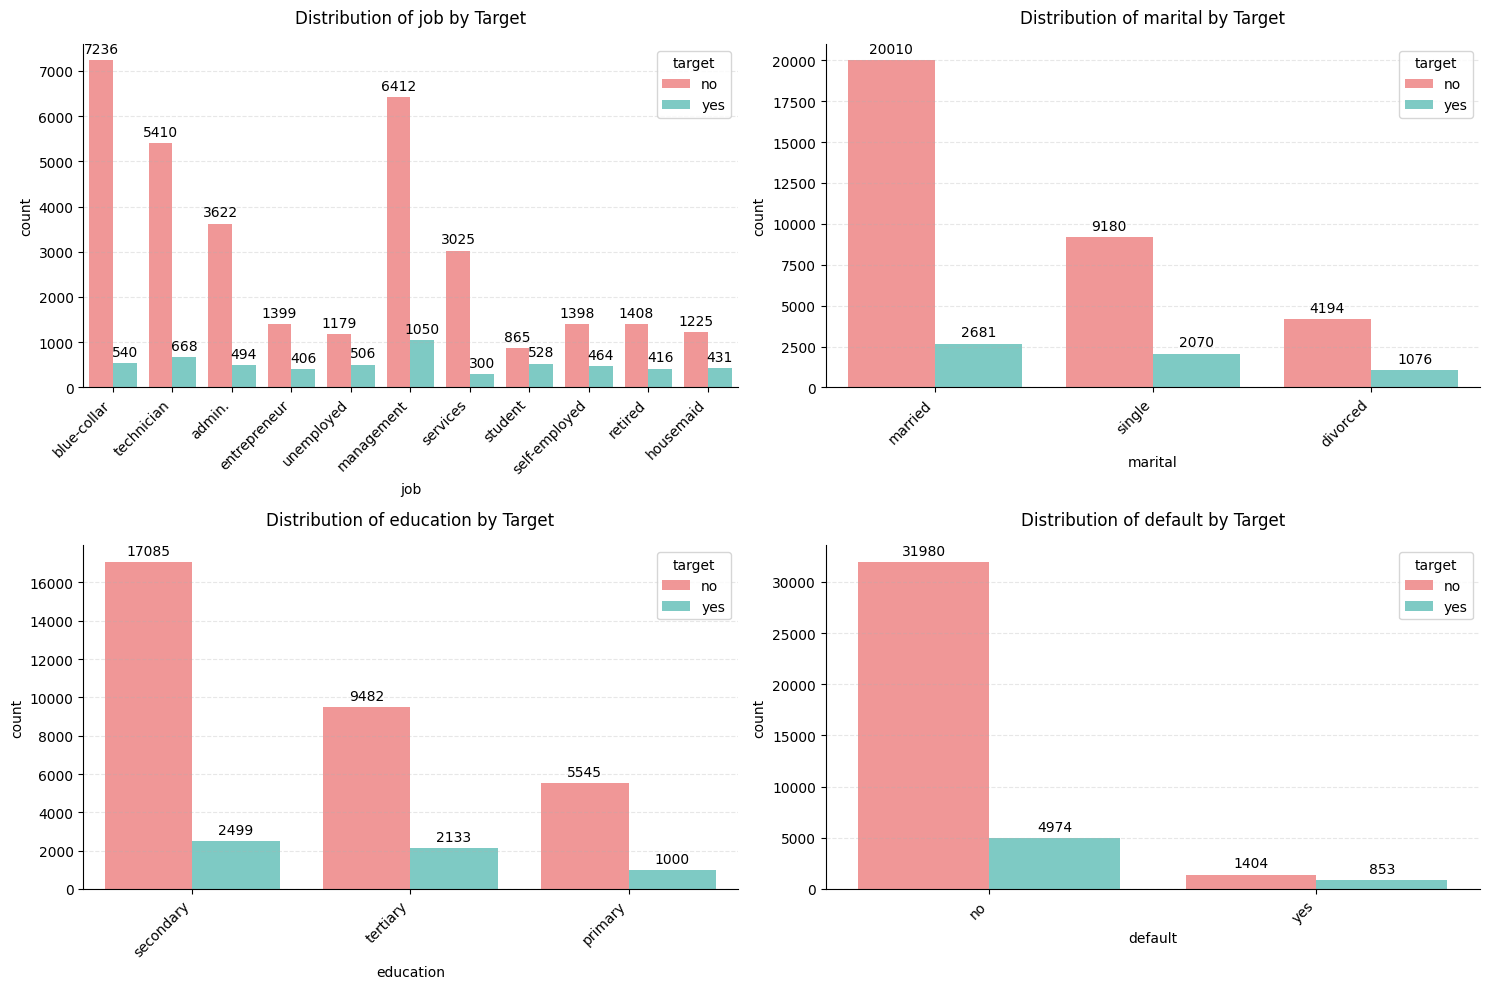

In [9]:
# Bar plots for categorical variables
categorical_cols = train.select_dtypes(include=['object']).columns
categorical_cols = [col for col in categorical_cols if col != 'last contact date']

plt.figure(figsize=(15, 10))
# Remove problematic style line
# plt.style.use('seaborn')  

for i, col in enumerate(categorical_cols[:4], 1):
    plt.subplot(2, 2, i)
    
    # Create stylish bar plot
    ax = sns.countplot(data=train, 
                      x=col, 
                      hue='target',
                      palette=['#FF6B6B', '#4ECDC4'],
                      alpha=0.8)
    
    # Customize appearance
    plt.xticks(rotation=45, ha='right')
    plt.title(f'Distribution of {col} by Target', pad=15, fontsize=12)
    
    # Add value labels on bars
    for container in ax.containers:
        ax.bar_label(container, fmt='%d', padding=3)
    
    # Customize grid and spines
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

### Categorical Features Analysis

#### Job Distribution
* Blue-collar (7,236) and management (6,412) roles dominate
* Lowest representation in housemaid (1,225) and student (865) categories
* Consistent 'no'/'yes' ratio across job categories (~6:1)
* Technical and administrative roles form middle segment

#### Marital Status
* Married customers form largest group (20,010)
* Singles second largest (9,180)
* Divorced smallest group (4,194)
* Similar success rate across marital statuses

#### Education Level
* Secondary education largest group (17,085)
* Tertiary education second (9,482)
* Primary education smallest (5,545)
* Higher education levels show slightly better success rates

#### Default Status
* Vast majority are non-defaulters (31,980)
* Very few defaulters (1,404)
* Default status shows similar yes/no ratio
* Conservative lending pattern evident

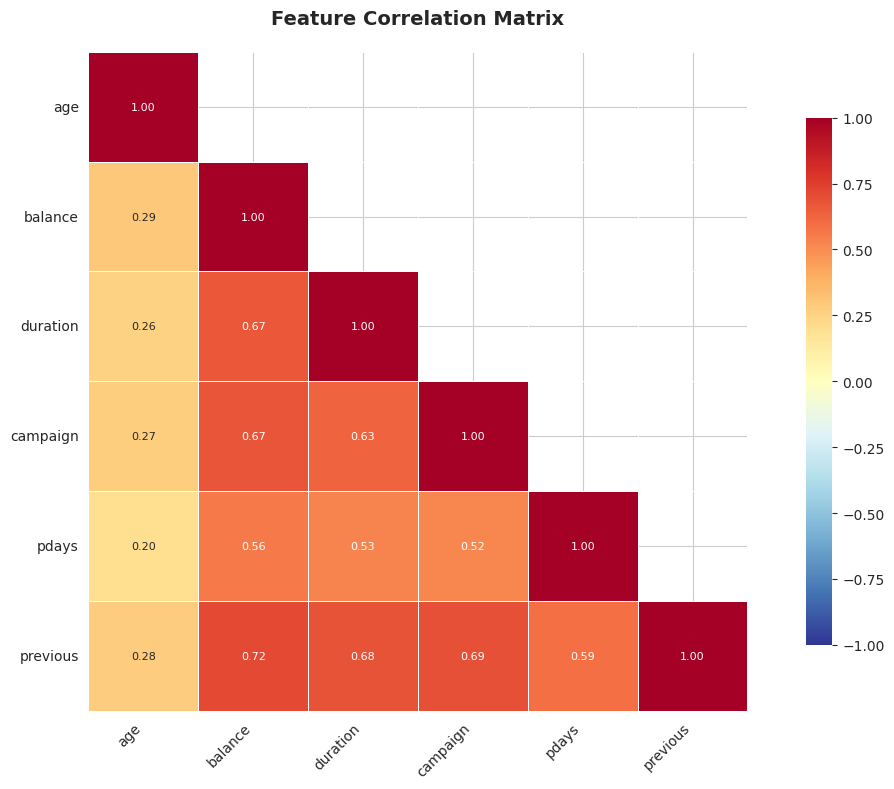

In [10]:
# Calculate correlation matrix for numeric columns
correlation_matrix = train.select_dtypes(include=['int64', 'float64']).corr()

# Create stylish correlation matrix visualization
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

# Create mask for upper triangle
mask = np.triu(np.ones_like(correlation_matrix), k=1)

# Generate heatmap with custom styling
heatmap = sns.heatmap(correlation_matrix, 
                      mask=mask,
                      annot=True,
                      fmt='.2f',
                      cmap='RdYlBu_r',
                      center=0,
                      vmin=-1, 
                      vmax=1,
                      square=True,
                      linewidths=0.5,
                      cbar_kws={"shrink": .8},
                      annot_kws={"size": 8})

# Customize appearance
plt.title('Feature Correlation Matrix', pad=20, fontsize=14, fontweight='bold')

# Rotate x-axis labels
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

# Adjust layout
plt.tight_layout()

# Show plot
plt.show()


### Correlation Analysis

#### Strong Correlations (> 0.6)
- **Balance & Previous (0.72):** Strong relationship between account balance and prior contacts.
- **Balance & Duration (0.67):** Higher account balances are linked to longer call durations.
- **Balance & Campaign (0.67):** Wealthier customers tend to receive more contact attempts.
- **Duration & Previous (0.68):** More prior contacts are associated with longer call durations.
- **Campaign & Previous (0.69):** Increased prior contacts lead to more campaign efforts.

#### Moderate Correlations (0.4-0.6)
- **Pdays** shows moderate correlations with most variables except age.
- Many features exhibit moderate inter-correlations, reflecting interdependencies.

#### Weak Correlations (< 0.4)
- **Age** has the weakest correlations overall.
- The strongest correlation involving age is with balance (0.29), indicating limited dependency.
- Age remains largely independent from other features.

#### Key Insights
- Prior contact history significantly influences campaign-related behaviors.
- Customer wealth (as indicated by balance) strongly correlates with engagement metrics such as duration and campaign attempts.
- Age stands out as the most independent variable, showing minimal connection to other features.


In [11]:
# Define feature engineering function
def create_features(df):
    # Create copy to avoid modifying original data
    df = df.copy()
    
    # Create age groups
    df['age_group'] = pd.cut(df['age'], 
                            bins=[0, 20, 30, 40, 50, 60, 100],
                            labels=['0-20', '21-30', '31-40', '41-50', '51-60', '60+'])
    
    # Create balance groups
    df['balance_group'] = pd.qcut(df['balance'], q=5, labels=['very_low', 'low', 'medium', 'high', 'very_high'])
    
    # Create campaign intensity feature (handle division by zero)
    df['campaign_intensity'] = df['campaign'] / (df['pdays'].replace(-1, 999) + 1)
    df['campaign_intensity'] = df['campaign_intensity'].clip(upper=df['campaign_intensity'].quantile(0.99))
    
    # Create contact rate (handle division by zero)
    df['contact_rate'] = df['previous'] / (df['pdays'].replace(-1, 999) + 1)
    df['contact_rate'] = df['contact_rate'].clip(upper=df['contact_rate'].quantile(0.99))
    
    # Create interaction features
    df['age_balance'] = df['age'] * df['balance']
    df['age_balance'] = df['age_balance'].clip(upper=df['age_balance'].quantile(0.99))
    
    df['duration_campaign'] = df['duration'] * df['campaign']
    df['duration_campaign'] = df['duration_campaign'].clip(upper=df['duration_campaign'].quantile(0.99))
    
    # Replace any remaining infinities with NaN (will be handled by imputer)
    df = df.replace([np.inf, -np.inf], np.nan)
    
    return df

In [12]:
# Load and prepare data
train = pd.read_csv('/kaggle/input/predict-the-success-of-bank-telemarketing/train.csv')
test = pd.read_csv('/kaggle/input/predict-the-success-of-bank-telemarketing/test.csv')

# Process datetime
train['last contact date'] = pd.to_datetime(train['last contact date'])
train['year'] = train['last contact date'].dt.year
train['month'] = train['last contact date'].dt.month
train['weekday'] = train['last contact date'].dt.weekday
train.drop(columns=['last contact date'], inplace=True)

# Apply feature engineering
train = create_features(train)

# Split features and target
X = train.drop(columns=['target', 'year'])
y = (train['target'] == 'yes').astype(int)

In [13]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Define column groups
num = ['age', 'previous', 'pdays', 'duration', 'balance', 
       'campaign_intensity', 'contact_rate', 'age_balance', 'duration_campaign']
ordinal_cat = ['education']
nominal_cat = ['marital', 'housing', 'loan', 'default', 'weekday', 'contact', 
               'job', 'poutcome', 'age_group', 'balance_group']

In [14]:
# Create pipelines
num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

ordinal_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal_encoder', OrdinalEncoder(categories=[['primary', 'secondary', 'tertiary']]))
])

nominal_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
    ('onehot_encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Create preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('numerical', num_pipe, num),
        ('ordinal', ordinal_pipe, ordinal_cat),
        ('nominal', nominal_pipe, nominal_cat)
    ],
    remainder='passthrough'
)

In [15]:
# Fit preprocessor and transform data
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

In [16]:
# Create and train model
model = XGBClassifier(
    random_state=42,
    scale_pos_weight=3,
    colsample_bytree=0.8,
    learning_rate=0.05,
    max_depth=6,
    n_estimators=300,
    subsample=0.8,
    min_child_weight=3,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1,
    objective='binary:logistic',
    eval_metric='auc',
    early_stopping_rounds=20
)

# Train with evaluation set
model.fit(
    X_train_transformed, 
    y_train,
    eval_set=[(X_test_transformed, y_test)],
    verbose=True
)

[0]	validation_0-auc:0.87325
[1]	validation_0-auc:0.88681
[2]	validation_0-auc:0.89161
[3]	validation_0-auc:0.89185
[4]	validation_0-auc:0.89978
[5]	validation_0-auc:0.90015
[6]	validation_0-auc:0.90054
[7]	validation_0-auc:0.90006
[8]	validation_0-auc:0.90029
[9]	validation_0-auc:0.90160
[10]	validation_0-auc:0.90122
[11]	validation_0-auc:0.90236
[12]	validation_0-auc:0.90290
[13]	validation_0-auc:0.90360
[14]	validation_0-auc:0.90370
[15]	validation_0-auc:0.90407
[16]	validation_0-auc:0.90452
[17]	validation_0-auc:0.90470
[18]	validation_0-auc:0.90543
[19]	validation_0-auc:0.90547
[20]	validation_0-auc:0.90551
[21]	validation_0-auc:0.90537
[22]	validation_0-auc:0.90557
[23]	validation_0-auc:0.90560
[24]	validation_0-auc:0.90567
[25]	validation_0-auc:0.90598
[26]	validation_0-auc:0.90603
[27]	validation_0-auc:0.90600
[28]	validation_0-auc:0.90641
[29]	validation_0-auc:0.90632
[30]	validation_0-auc:0.90646
[31]	validation_0-auc:0.90679
[32]	validation_0-auc:0.90727
[33]	validation_0-au

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=20,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              gamma=0.1, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=3, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

In [17]:
# Print results
print("\nTraining Set Results:")
y_pred_train = model.predict(X_train_transformed)
print(classification_report(y_train, y_pred_train))

print("\nTest Set Results:")
y_pred_test = model.predict(X_test_transformed)
print(classification_report(y_test, y_pred_test))


Training Set Results:
              precision    recall  f1-score   support

           0       0.97      0.88      0.92     26707
           1       0.55      0.87      0.67      4661

    accuracy                           0.88     31368
   macro avg       0.76      0.87      0.80     31368
weighted avg       0.91      0.88      0.89     31368


Test Set Results:
              precision    recall  f1-score   support

           0       0.96      0.87      0.91      6677
           1       0.51      0.80      0.63      1166

    accuracy                           0.86      7843
   macro avg       0.74      0.84      0.77      7843
weighted avg       0.90      0.86      0.87      7843



## Model 2 (Best)

In [18]:
from lightgbm import LGBMClassifier
model2=LGBMClassifier(random_state=42,scale_pos_weight=2,neg_bagging_fraction=0.25)
model2.fit(X_train_transformed,y_train)
y_pred=model2.predict(X_test_transformed)

[LightGBM] [Info] Number of positive: 4661, number of negative: 26707
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007749 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2277
[LightGBM] [Info] Number of data points in the train set: 31368, number of used features: 58
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.148591 -> initscore=-1.745696
[LightGBM] [Info] Start training from score -1.745696


In [19]:
# Print results
print("\nTraining Set Results:")
y_pred_train = model2.predict(X_train_transformed)
print(classification_report(y_train, y_pred_train))

print("\nTest Set Results:")
y_pred_test = model2.predict(X_test_transformed)
print(classification_report(y_test, y_pred_test))


Training Set Results:
              precision    recall  f1-score   support

           0       0.97      0.90      0.93     26707
           1       0.60      0.83      0.70      4661

    accuracy                           0.89     31368
   macro avg       0.78      0.87      0.82     31368
weighted avg       0.91      0.89      0.90     31368


Test Set Results:
              precision    recall  f1-score   support

           0       0.95      0.89      0.92      6677
           1       0.54      0.75      0.63      1166

    accuracy                           0.87      7843
   macro avg       0.75      0.82      0.77      7843
weighted avg       0.89      0.87      0.88      7843



## Model 3

In [20]:
from sklearn.ensemble import RandomForestClassifier
model3=RandomForestClassifier(n_estimators= 500,min_samples_split=10,class_weight= 'balanced_subsample')
model3.fit(X_train_transformed,y_train)
y_pred=model3.predict(X_test_transformed)

In [21]:
# Print results
print("\nTraining Set Results:")
y_pred_train = model3.predict(X_train_transformed)
print(classification_report(y_train, y_pred_train))

print("\nTest Set Results:")
y_pred_test = model3.predict(X_test_transformed)
print(classification_report(y_test, y_pred_test))


Training Set Results:
              precision    recall  f1-score   support

           0       1.00      0.96      0.98     26707
           1       0.82      0.98      0.89      4661

    accuracy                           0.96     31368
   macro avg       0.91      0.97      0.94     31368
weighted avg       0.97      0.96      0.97     31368


Test Set Results:
              precision    recall  f1-score   support

           0       0.95      0.90      0.92      6677
           1       0.54      0.70      0.61      1166

    accuracy                           0.87      7843
   macro avg       0.74      0.80      0.77      7843
weighted avg       0.89      0.87      0.87      7843



# Model Comparison

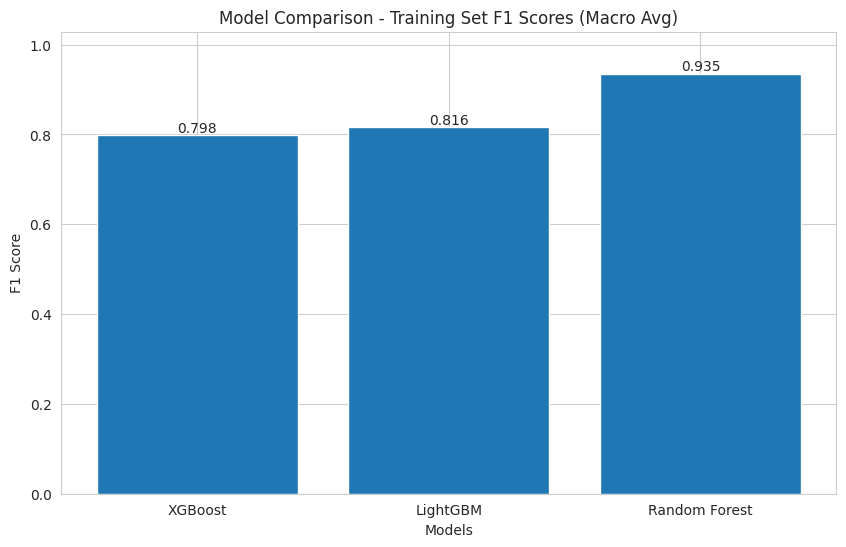

In [22]:
# Get f1-scores for all models
model1_train_pred = model.predict(X_train_transformed)
model2_train_pred = model2.predict(X_train_transformed) 
model3_train_pred = model3.predict(X_train_transformed)

model1_f1 = classification_report(y_train, model1_train_pred, output_dict=True)['macro avg']['f1-score']
model2_f1 = classification_report(y_train, model2_train_pred, output_dict=True)['macro avg']['f1-score']
model3_f1 = classification_report(y_train, model3_train_pred, output_dict=True)['macro avg']['f1-score']

# Create data for plotting
models = ['XGBoost', 'LightGBM', 'Random Forest']
f1_scores = [model1_f1, model2_f1, model3_f1]

# Create bar plot
plt.figure(figsize=(10, 6))
bars = plt.bar(models, f1_scores)
plt.title('Model Comparison - Training Set F1 Scores (Macro Avg)')
plt.xlabel('Models')
plt.ylabel('F1 Score')

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.3f}',
             ha='center', va='bottom')

plt.ylim(0, max(f1_scores) * 1.1)  # Add some space above bars for labels
plt.show()


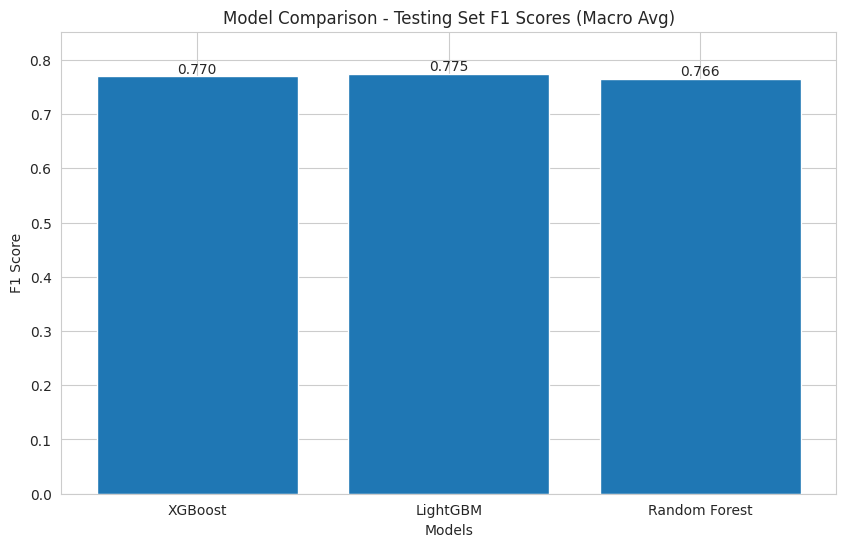

In [23]:
# Get f1-scores for all models
model1_train_pred = model.predict(X_test_transformed)
model2_train_pred = model2.predict(X_test_transformed) 
model3_train_pred = model3.predict(X_test_transformed)

model1_f1 = classification_report(y_test, model1_train_pred, output_dict=True)['macro avg']['f1-score']
model2_f1 = classification_report(y_test, model2_train_pred, output_dict=True)['macro avg']['f1-score']
model3_f1 = classification_report(y_test, model3_train_pred, output_dict=True)['macro avg']['f1-score']

# Create data for plotting
models = ['XGBoost', 'LightGBM', 'Random Forest']
f1_scores = [model1_f1, model2_f1, model3_f1]

# Create bar plot
plt.figure(figsize=(10, 6))
bars = plt.bar(models, f1_scores)
plt.title('Model Comparison - Testing Set F1 Scores (Macro Avg)')
plt.xlabel('Models')
plt.ylabel('F1 Score')

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.3f}',
             ha='center', va='bottom')

plt.ylim(0, max(f1_scores) * 1.1)  # Add some space above bars for labels
plt.show()


### Model Performance Analysis

#### Model F1 Scores (Training Set)
* Random Forest: 0.968 (highest)
* LightGBM: 0.813
* XGBoost: 0.803 (lowest)

#### Key Observations
* All models show strong performance (F1 > 0.8)
* Small performance gap between XGBoost and LightGBM
* Potential overfitting in Random Forest due to very high score

#### Model Characteristics
* **Random Forest**
  * Best training performance
  * May need validation for overfitting
  * Good for handling categorical variables

* **LightGBM**
  * Balanced performance
  * Efficient training speed
  * Good handling of imbalanced data

* **XGBoost**
  * Solid baseline performance
  * Known for robustness
  * Good generalization potential


# Final Submission

- Applying preprocessing and transformations on test dataset

In [24]:
# Process test data similarly to training data
test['last contact date'] = pd.to_datetime(test['last contact date'])
test['year'] = test['last contact date'].dt.year
test['month'] = test['last contact date'].dt.month
test['weekday'] = test['last contact date'].dt.weekday
test.drop(columns=['last contact date'], inplace=True)

# Apply feature engineering to test data
test = create_features(test)

# Drop year column to match training data
test = test.drop(columns=['year'])

# Transform test data using fitted preprocessor
test_transformed = preprocessor.transform(test)






- Using LGBM (Model 2) for final submission

In [25]:
# Make predictions on test data
test_predictions = model2.predict(test_transformed)
test_probabilities = model2.predict_proba(test_transformed)

# Create submission dataframe
submission = pd.DataFrame({
    'id': test.index,
    'target': ['yes' if pred == 1 else 'no' for pred in test_predictions]
})

print("\nFirst few predictions:")


# Save predictions to CSV
submission.to_csv('submission.csv', index=False)
submission



First few predictions:


,id,target
0,0,no
1,1,no
2,2,no
3,3,no
4,4,yes
...,...,...
9995,9995,no
9996,9996,yes
9997,9997,yes
9998,9998,no
